# Operational Comparison of Two Companies


This analysis compared the operations of the two companies, Company A and Company B. Since Company A has a scooter ID data whereas Company B does not, Company A is assumed to be a stakeholder who seeks to operational recommendation based on findings from this data analysis. Followings are the summary of insights found from this analysis.

### Data
Company A's data covers an earlier period (2018-08 to 2018-12), while Company B's data covers a later period (2018-12 to 2019-01), overlapping with Company A during December.

* The Total Driven miles is used as an indicator of total usage, assuming it correlates with revenue. 
* Geographical area is segmented to Downtown, University, and Residential areas, which show distinct operational patterns.

### Summary of Findings
* Company A shows gradually decreasing usage over the time, including in December, where Company B shows increasing usage.
* In December, Company A experienced a significant decrease in usage particularly in the University area, whereas this appears to be an area where Company B focused on operation sucessfully (including January).
* Overall, Company B seems to focus on University commuters (users concentrated in University areas, morning users, more University users on weekdays than weekends), while Company A focuses on after-work users (users concentrated in afternoon operations, many users in downtown and residential areas, and increased usage in these areas on weekends).
* Company A's decrease in users as the weather gets colder might be because most users are not outdoor when the weather is cold. 
* Operating more scooters didn't increase usage over time at all for Company A. It seems to increases unnecessary expenses only. Company A needs different strategy.

### Recommendation
* For Company A to increase usage during cold seasons, they need to find targets who use scooters regardless of weather. Focusing on university commuters like Company B seems to be a good strategy.
* Recommend to refer what Company B does to capture university commuters. For example, one can imagine offering discounts to regular commuter users.
* In addition, since Company A's usage is higher during warm weather, weekends, afternoon hours, and in downtown, increasing prices under similar conditions may generate more revenue.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plot_utils import melt_df_for_subplot, plot_features, plot_heatmap
import matplotlib.image as mpimg


from preprocess_data import get_all_data_frames, get_distance_meters, miles_to_meters

In [2]:
# Load data
# Ignore warnings
df_dict = get_all_data_frames() 
df = df_dict['df']
#df_uncleaned = df_dict['df_uncleaned']
df_week = df_dict['df_week']
df_week_all_area = df_dict['df_week_all_area']
df_day = df_dict['df_day']
df_hour = df_dict['df_hour']
df_day_hour = df_dict['df_day_hour']
df_day_december = df_dict['df_day_december']
df_hour_december = df_dict['df_hour_december']
df_day_hour_december = df_dict['df_day_hour_december']

/Users/minjungkim/Developer/company_compare/preprocess_data.py:86: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_b['week'] = df_b.start_time.dt.tz_convert('US/Eastern').dt.to_period('W').dt.start_time


## Trend of Potential Revenue and Cost
### Assumption
* The total driven miles as an indicator for revenue
* The number of scooters as an indicator for revenue
* The operational hours per day per scooter as an indicator for revenue for fleet utilization efficiency

### Fig 1. Potential Revenue Tend
* Weekly driven miles for Company A decline through late fall and winter, indicating a potential drop in revenue, may be related to colder weather
* In contrast, weekly driven miles for Company B’s continue to rise over the same period (December 2018), may due to effective winter operations


### Fig 2. Operational Cost of Company A
* Company A increased the number of scooters in operation over time (left plot), but the fleet utilization efficiency dropped significantly over the fall and winter (right plot)

### Summary
* Company A is experiencing a drop in driven miles, indicating revenue drop
* Company B saw an increase of driven miles in December
* Increasing the number of scooters may not result in increased revenue

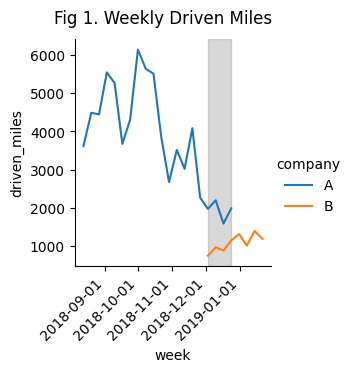

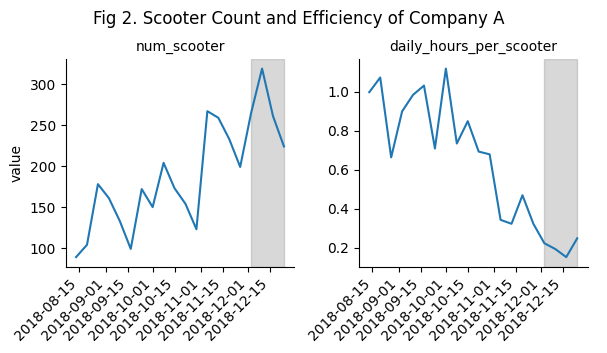

In [3]:
plot_features('Fig 1. Weekly Driven Miles',
    df=df_week_all_area,
    x='week', y='driven_miles', 
    hue='company', col=None, 
    sharey=True, x_rotate=True, dec_bar=True, melt=False)

df_draw = melt_df_for_subplot(df_week_all_area[df_week_all_area.company=='A'],
        x_vars=['week','company'], 
        y_vars=['num_scooter','daily_hours_per_scooter',],
        )
plot_features('Fig 2. Scooter Count and Efficiency of Company A',
    df=df_draw,
    x='week', y='value', 
    hue=None, col='feature', 
    sharey=False, x_rotate=True, dec_bar=True, melt=True)

## Geographical Coverage
### Ride Distances
* Company A
    * More than half rides within 0.9 mile
    * More than 75% rides within 2 miles.
* Company B
    * More than half rides within 0.6 mile
    * More than 75% rides within 1.2 miles.
* Both companies have short rides, majorities of rides are less than 2 miles and under 20 minues, while Company B tends to have shorter rides.

In [4]:
# Get data range
print("Distance coverage (miles):")
display(df.groupby('company').distance_mile.describe().reset_index()[['company','mean','min','50%','75%','max']].set_index('company'))
print("Duration coverage (minutes):")
display(df.groupby('company').duration_minute.describe().reset_index()[['company','mean','min','50%','75%','max']].set_index('company'))

Distance coverage (miles):


,mean,min,50%,75%,max
company,,,,,
A,1.544322,0.010000,0.900000,1.930000,20.880000
B,0.947839,0.003728,0.594654,1.119714,22.655871


Duration coverage (minutes):


,mean,min,50%,75%,max
company,,,,,
A,17.381494,1.0,10.0,21.000000,3167.0
B,13.627413,0.2,6.5,14.066667,696.8


### Fig 3-4. Ride Locations
* Both companies operate in the same region (Louisville, Kentucky), confirmed by matching their coordinates on google maps
* Similar popular pickup areas, peaks at 
    * Downtown (yellow box in Fig 4)
    * University (orange box in Fig 4)
    * Residential (magenta box in Fig 4)
* Distinct highest pickup locations
    * Company A: Downtown
    * Company B: University
* Note
    * Data taking period is different between two company, so the effect may include seasonality

#### Area Segmentation
* Green lines segment the area into three groups for this analysis:
    * (start_longitude < -85.73) && (start_latitude > 38.24): Downtown area
    * (start_longitude < -85.73) && (start_latitude <= 38.24): University area
    * (start_longitude >= -85.73): Residential area
* Note
    * 0.01 degree in latitude or longitude corresponds to approximately 1 mile
    * Considering majorities of ride distances are less than 2 miles, most rides in one peak area are not likely to reach to a different peak area
    * To avoid confusion, the geographical coverage of the Fig 4. larger than that of Fig 3, having different height-width ratio

0.01 degree corresponds to 0.9771295893211902  miles


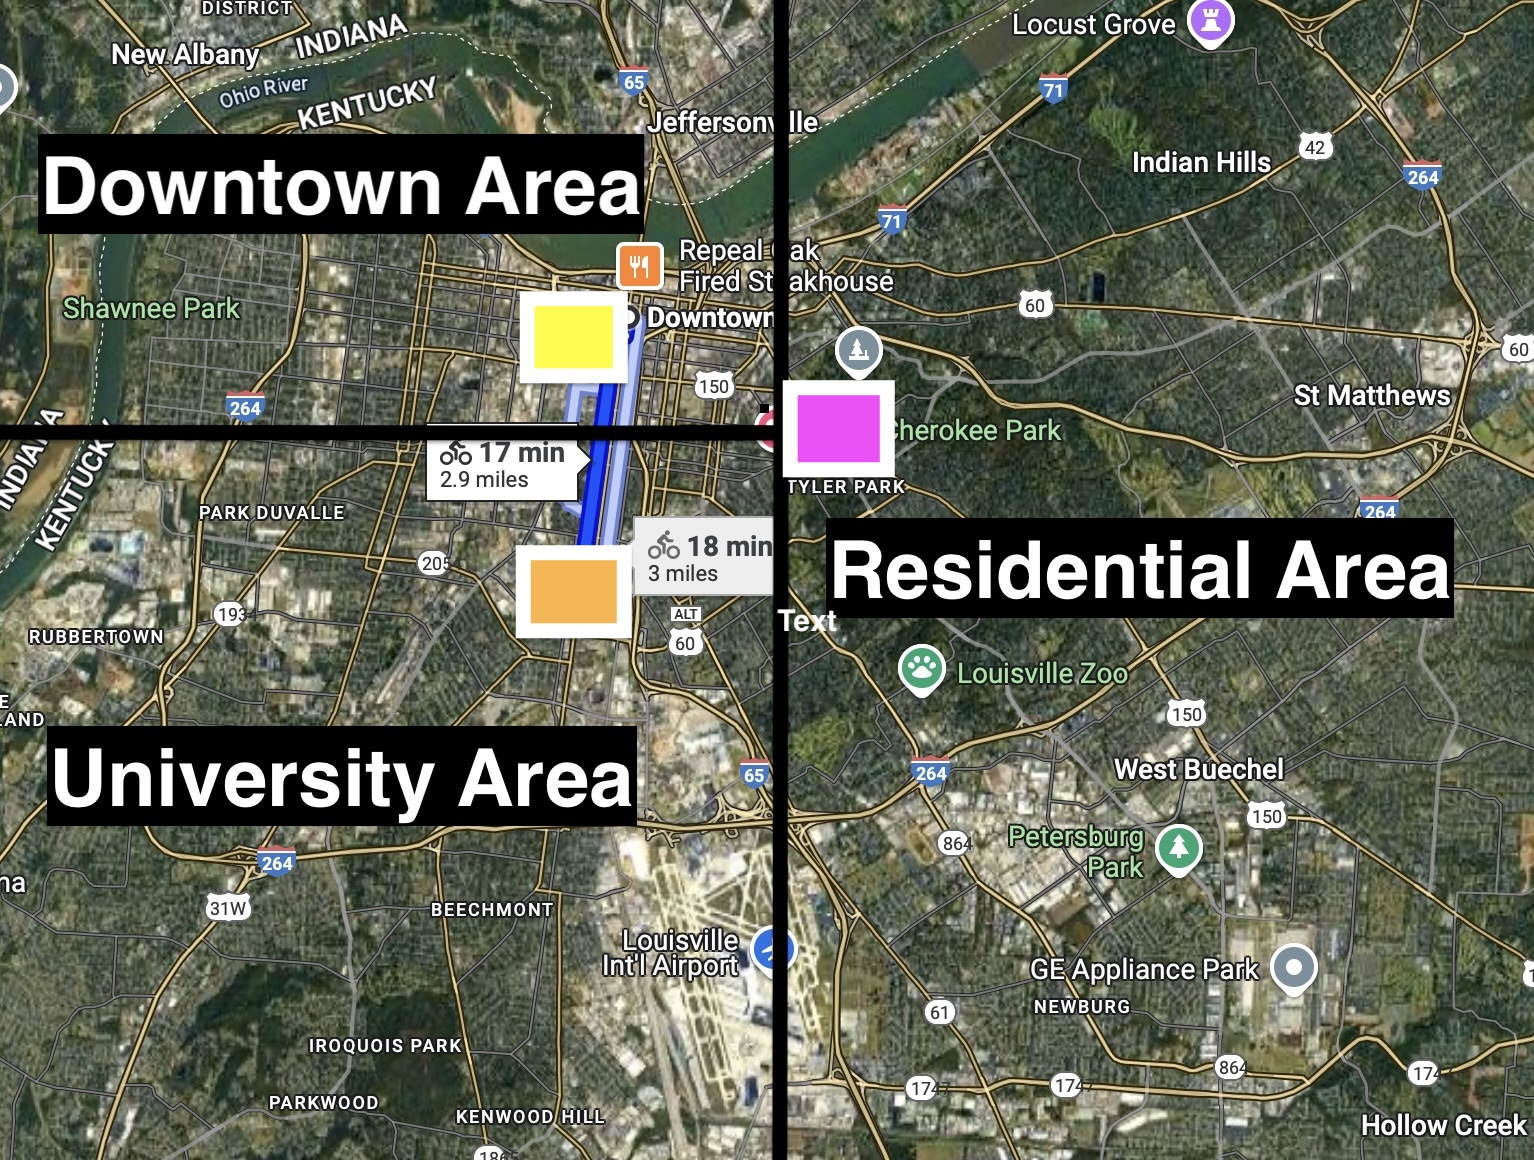

In [5]:
# Scale degrees in miles
print('0.01 degree corresponds to', get_distance_meters(0.01,0.01,0,0)/miles_to_meters, ' miles')

# Draw a 2D histogram for a pick up location (ride start location)
fig = px.density_heatmap(
    df, x="start_longitude", y="start_latitude", 
    range_x=[-85.81, -85.66], range_y=[38.15, 38.30],
    facet_col="company",
    title="Fig 3. Pick-up locations"
    )
# Add area segmentation lines
fig.add_trace(go.Scatter(
    mode='lines', x= [-85.9, -85.73], y= [38.24, 38.24],
    line=dict(color='green',width=2), showlegend=False
    ), row="all", col="all"
    ).add_trace(go.Scatter(
    mode='lines', x= [-85.73, -85.73], y= [38.1, 38.4],
    line=dict(color='green',width=2), showlegend=False
   ), row="all", col="all")
fig.show()

# Overlay area segmentation lines on the google map
from IPython.display import Image, display
display(Image('fig/gmap.jpg'))

## Operational Features
### Fig 5-8. Trends
* The gray bar highlights the overlapping period of the two companies (December)
* Different areas show distinct trends over time
    * Downtown & Residential: driven miles and ride drop in late fall and winter
    * University: significant increases in late fall and winter, tends to be short rides (around a mile) 
* Driving distance per ride decreases as the weather gets colder
    * Except a sudden surge in late December
* In December, while Company A experiences a drop in ride count in the University area, Company B sees an increase, which grows further in January
* Fleet utilization rate is highest in Downtown, although decreasing trend is observed for every area

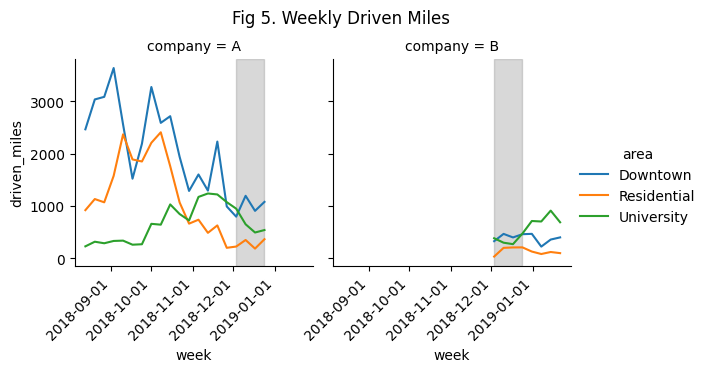

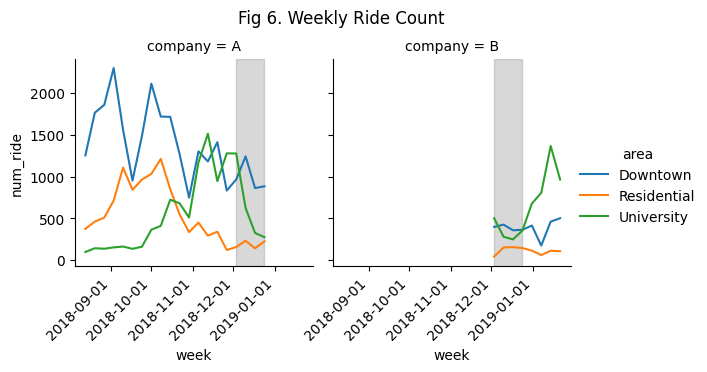

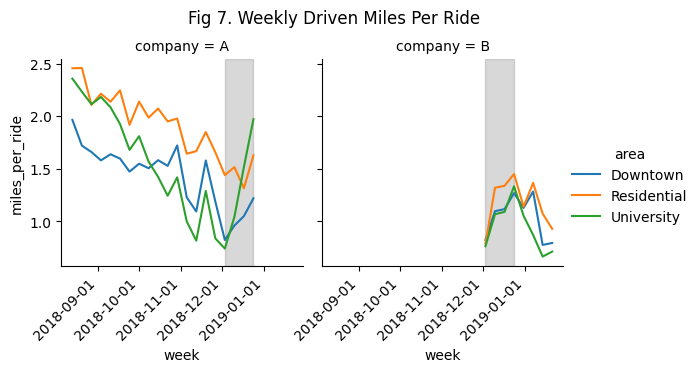

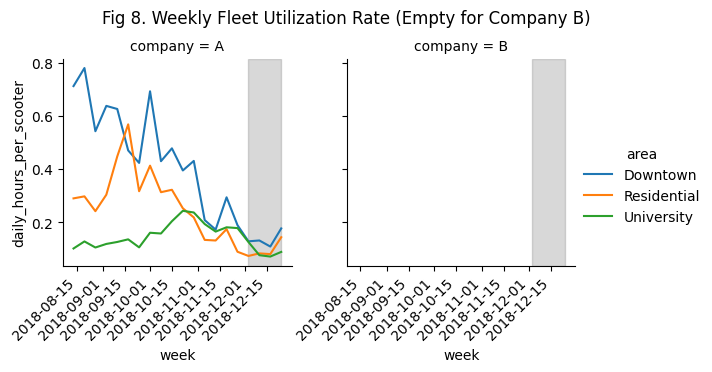

In [6]:
plot_features('Fig 5. Weekly Driven Miles',
    df=df_week,
    x='week', y='driven_miles', 
    hue='area', col='company', 
    sharey=True, x_rotate=True, dec_bar=True, melt=False)
plot_features('Fig 6. Weekly Ride Count',
    df=df_week,
    x='week', y='num_ride', 
    hue='area', col='company', 
    sharey=True, x_rotate=True, dec_bar=True, melt=False)
plot_features('Fig 7. Weekly Driven Miles Per Ride',
    df=df_week,
    x='week', y='miles_per_ride', 
    hue='area', col='company', 
    sharey=True, x_rotate=True, dec_bar=True, melt=False)
plot_features('Fig 8. Weekly Fleet Utilization Rate (Empty for Company B)',
    df=df_week,
    x='week', y='daily_hours_per_scooter', 
    hue='area', col='company', 
    sharey=True, x_rotate=True, dec_bar=True, melt=False)

### Fig 9-11. Weekday Patterns
Weekly pattern for each area are similar between companies
* Weekend
    * Overall revenue increased  (Fig 9)
        * Except University area of Company B
    * Each ride tend to be longer (Fig 11)
* Weekday
    * More ride count in University area (Fig 10), which tend to be short ride (Fig 11)
* Company A
    * Expect highest revenue in weekends, highest from Downtown, followed by Residential areas (Fig 9. Left)
* Company B
    * Expect highest weekday revenue from University, then highest weekend revenue from downtown, followed by residential areas (Fig 9. Right)
* Note
    * Company A and Company B data cover different season. The difference may come from seasonal effect partially.


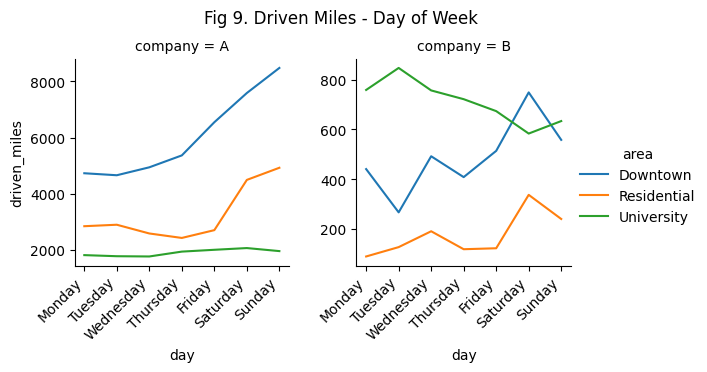

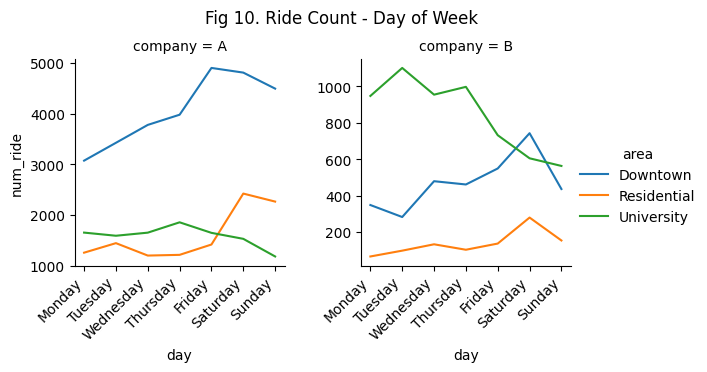

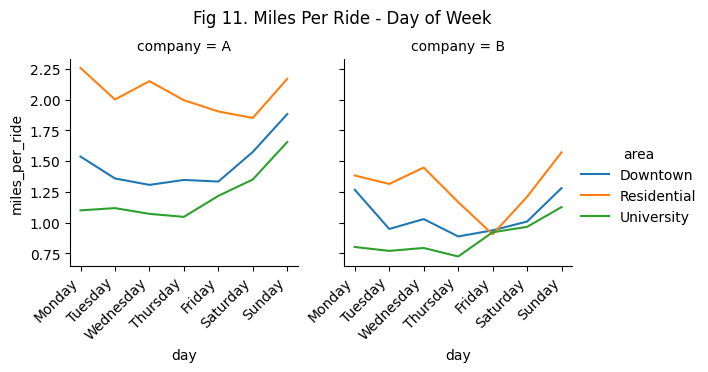

In [7]:
plot_features('Fig 9. Driven Miles - Day of Week',
    df=df_day,
    x='day', y='driven_miles', 
    hue='area', col='company', 
    sharey=False, x_rotate=True, dec_bar=False, melt=False)
plot_features('Fig 10. Ride Count - Day of Week',
    df=df_day,
    x='day', y='num_ride', 
    hue='area', col='company', 
    sharey=False, x_rotate=True, dec_bar=False, melt=False)
plot_features('Fig 11. Miles Per Ride - Day of Week',
    df=df_day,
    x='day', y='miles_per_ride', 
    hue='area', col='company', 
    sharey=True, x_rotate=True, dec_bar=False, melt=False)

### Fig 12-14. Hourly Patterns
Unlike weekday patterns, hourly patterns show distinct pattern between two companies significantly
* Company A
    * Peak in the afternoon, regardless of area (Fig 12-13)
* Company B
    * Peak in the morning, regardless of area, seemingly for commute  (Fig 12-13)
* Long driving ride at late night hours, seemingly due to unavailable public transportation (Fig 14)
* Note
    * Company A and Company B data cover different season. The difference may come from seasonal effect partially.

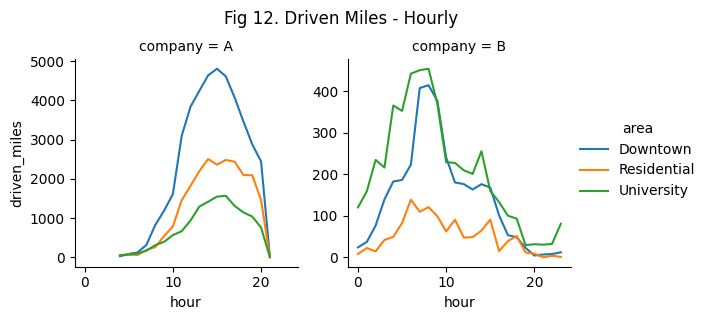

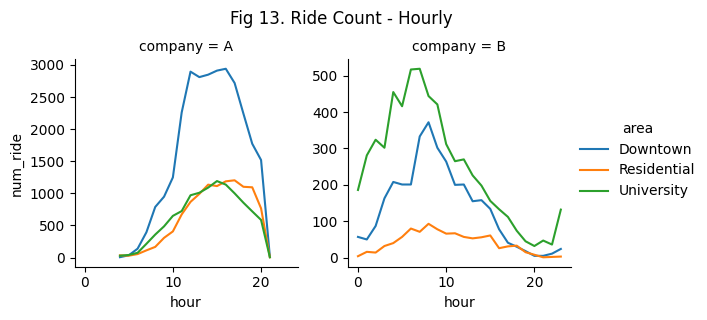

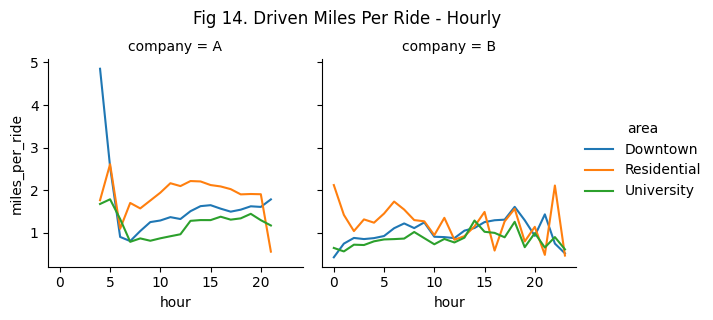

In [8]:
plot_features('Fig 12. Driven Miles - Hourly',
    df=df_hour,
    x='hour', y='driven_miles', 
    hue='area', col='company', 
    sharey=False, x_rotate=False, dec_bar=False, melt=False)
plot_features('Fig 13. Ride Count - Hourly',
    df=df_hour,
    x='hour', y='num_ride', 
    hue='area', col='company', 
    sharey=False, x_rotate=False, dec_bar=False, melt=False)
plot_features('Fig 14. Driven Miles Per Ride - Hourly',
    df=df_hour,
    x='hour', y='miles_per_ride', 
    hue='area', col='company', 
    sharey=True, x_rotate=False, dec_bar=False, melt=False)

In [9]:
# Unused becaust there's no extra information with this data
# plot_heatmap('Peak Ride Time', df_day_hour, 'num_ride')

### Fig 15-17. Weekday Patterns, December Only
Same plots as Fig 9-11 except now plots are drawn only for December data in order remove seasonality effect when comparing operation of companies

By comparing with Fig 9-11,
* Most patterns are similar except University area of Company B follows different trend, higher ride in weekend (as opposed to Fig 9-11)


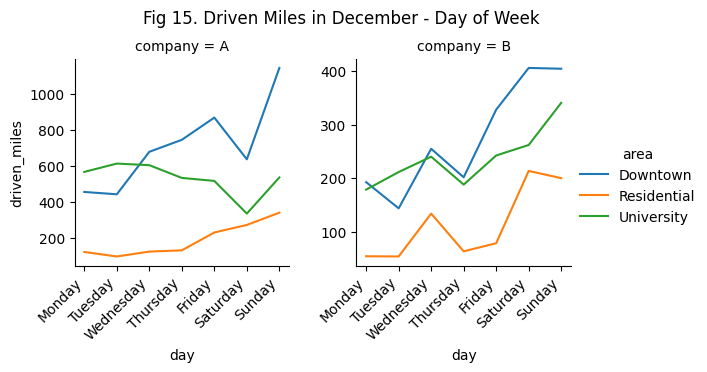

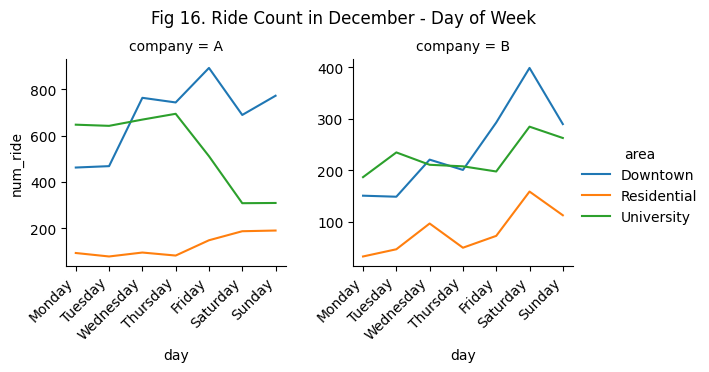

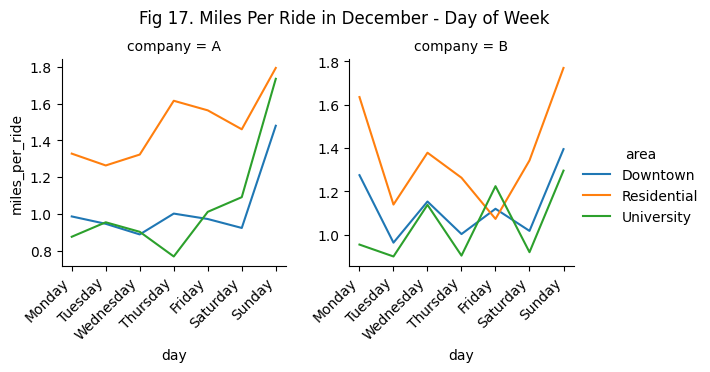

In [10]:
plot_features('Fig 15. Driven Miles in December - Day of Week',
    df=df_day_december,
    x='day', y='driven_miles', 
    hue='area', col='company', 
    sharey=False, x_rotate=True, dec_bar=False, melt=False)
plot_features('Fig 16. Ride Count in December - Day of Week',
    df=df_day_december,
    x='day', y='num_ride', 
    hue='area', col='company', 
    sharey=False, x_rotate=True, dec_bar=False, melt=False)
plot_features('Fig 17. Miles Per Ride in December - Day of Week',
    df=df_day_december,
    x='day', y='miles_per_ride', 
    hue='area', col='company', 
    sharey=False, x_rotate=True, dec_bar=False, melt=False)

### Fig 18-20. Hourly Patterns in December Only
Same plots as Fig 12-14 except now plots are drawn only for December data in order remove seasonality effect when comparing operation of companies
* By comparing with Fig 12-14, patterns look similar

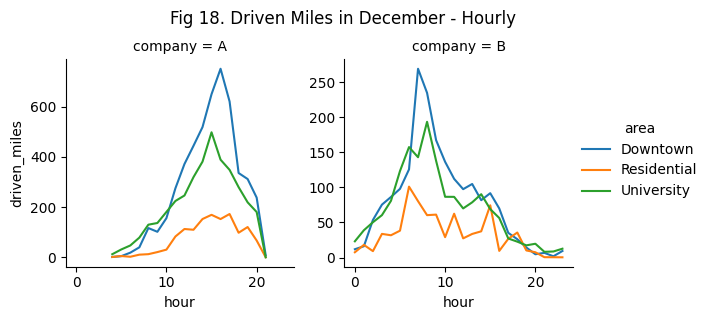

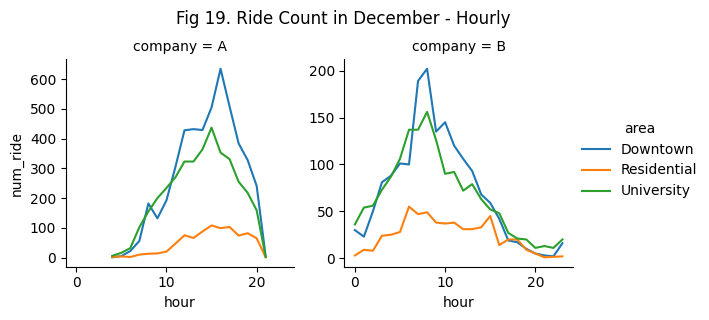

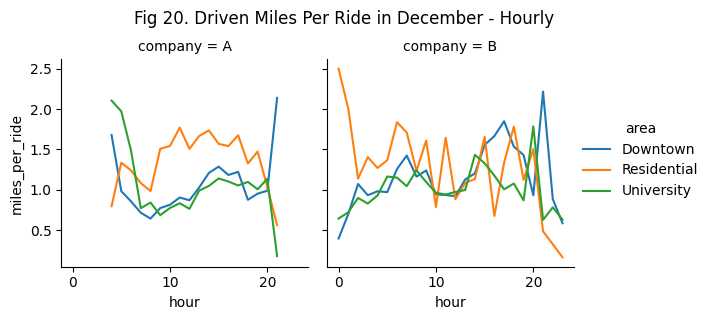

In [11]:
plot_features('Fig 18. Driven Miles in December - Hourly',
    df=df_hour_december,
    x='hour', y='driven_miles', 
    hue='area', col='company', 
    sharey=False, x_rotate=False, dec_bar=False, melt=False)
plot_features('Fig 19. Ride Count in December - Hourly',
    df=df_hour_december,
    x='hour', y='num_ride', 
    hue='area', col='company', 
    sharey=False, x_rotate=False, dec_bar=False, melt=False)
plot_features('Fig 20. Driven Miles Per Ride in December - Hourly',
    df=df_hour_december,
    x='hour', y='miles_per_ride', 
    hue='area', col='company', 
    sharey=True, x_rotate=False, dec_bar=False, melt=False)